# Методы обучения без учителя.

In [1]:
import pandas as pd

### 1. Выберите набор данных (датасет) для решения задачи обучения без учителя.

In [2]:
data = pd.read_csv('Mall_Customers.csv', sep=",")

In [5]:
# размер набора данных
data.shape

(200, 5)

In [6]:
# типы колонок
data.dtypes

CustomerID                int64
Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

In [7]:
data.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

### 2. Выберите подмножество признаков датасета для анализа. Например, подмножество признаков может не включать целевой признак. Количество признаков в подмножестве должно быть более двух. Полученный датасет назовем датасетом D1.

In [9]:
D1 = data[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

D1.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


Датасет D1 — это исходный набор данных, в котором:

- удаляется целевая переменная (если она есть)
- выбирается подмножество признаков (более 2)

Цель:

- оставить только числовые признаки, описывающие объекты
- подготовить данные для анализа структуры

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
D1_scaled = scaler.fit_transform(D1)

### 3. С использованием метода главных компонент проведите для датасета D1 снижение размерности данных до двух. Полученный датасет назовем датасетом D2.

In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
D2 = pca.fit_transform(D1_scaled)

### 4. С использованием алгоритма t-SNE также проведите для датасета D1 снижение размерности данных до двух. Полученный датасет назовем датасетом D3.

In [15]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
D3 = tsne.fit_transform(D1_scaled)

### 5. Визуализируйте точки датасетов D2 и D3. В каком случае кластеры выделены наиболее явно?

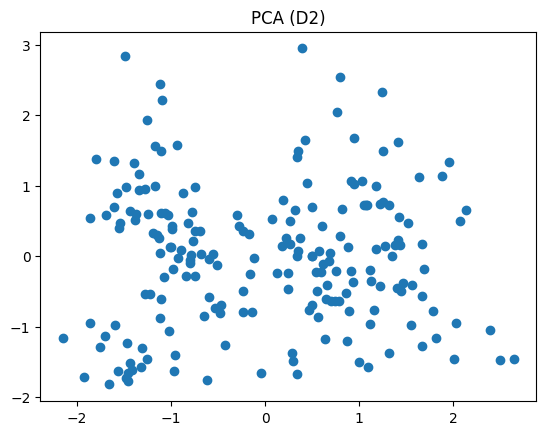

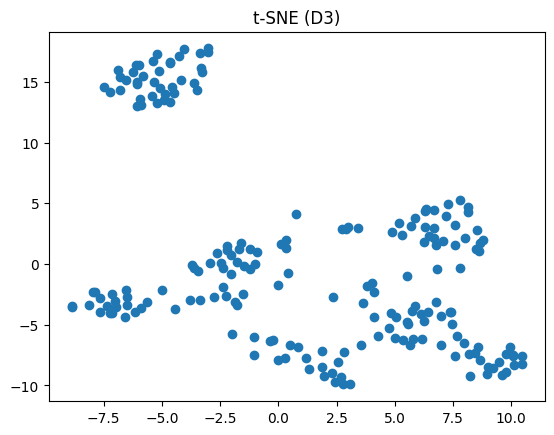

In [16]:
import matplotlib.pyplot as plt

plt.scatter(D2[:,0], D2[:,1])
plt.title("PCA (D2)")
plt.show()

plt.scatter(D3[:,0], D3[:,1])
plt.title("t-SNE (D3)")
plt.show()

На визуализации t-SNE (D3) кластеры разделены более явно, чем на PCA (D2).
Это выражается в формировании компактных и изолированных групп точек.
В случае PCA наблюдается частичное пересечение кластеров, что связано с линейной природой метода и сохранением глобальной дисперсии, а не локальной структуры.

### 6. Для датасетов D1, D2 и D3 проведите кластеризацию с использованием как минимум трех методов кластеризации, рассмотренных в лекции. Оцените качество кластеризации с использованием метрик, рассмотренных в лекции.

In [17]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

from sklearn.metrics import silhouette_score, adjusted_rand_score, adjusted_mutual_info_score

In [18]:
kmeans = KMeans(n_clusters=5, random_state=42)
labels_kmeans = kmeans.fit_predict(D1_scaled)

In [19]:
agg = AgglomerativeClustering(n_clusters=5)
labels_agg = agg.fit_predict(D1_scaled)

In [20]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_db = dbscan.fit_predict(D1_scaled)

In [29]:
def evaluate(name, X, labels):
    print(f"\n{name}")

    if len(set(labels)) > 1 and -1 not in set(labels):
        print("Silhouette:", silhouette_score(X, labels))
    else:
        try:
            print("Silhouette:", silhouette_score(X, labels))
        except:
            print("Silhouette: not defined (single cluster or noise)")

    print("Кластеров:", len(set(labels)))

In [30]:
evaluate("KMeans на D1", D1_scaled, labels_kmeans)
evaluate("Agglomerative на D1", D1_scaled, labels_agg)
evaluate("DBSCAN на D1", D1_scaled, labels_db)


KMeans на D1
Silhouette: 0.40846873777345605
Кластеров: 5

Agglomerative на D1
Silhouette: 0.39002826186267214
Кластеров: 5

DBSCAN на D1
Silhouette: 0.18451372756506046
Кластеров: 7


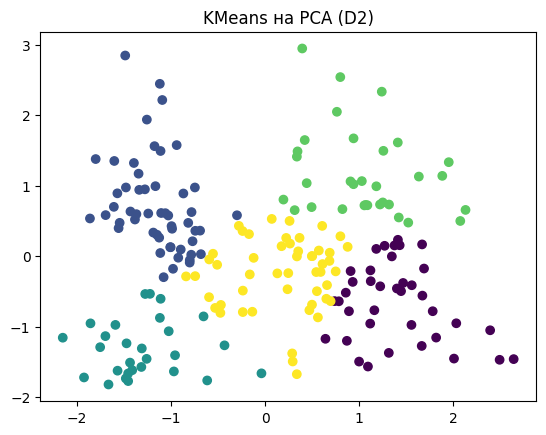


KMeans на D2
Silhouette: 0.38978616968277185
Кластеров: 5

Agglomerative на D2
Silhouette: 0.38063103681701316
Кластеров: 5

DBSCAN на D2
Silhouette: 0.3203118288175695
Кластеров: 2


In [38]:
labels_kmeans_d2 = KMeans(n_clusters=5, random_state=42).fit_predict(D2)
labels_agg_d2 = AgglomerativeClustering(n_clusters=5).fit_predict(D2)
labels_db_d2 = DBSCAN(eps=0.5, min_samples=5).fit_predict(D2)

plt.scatter(D2[:,0], D2[:,1], c=labels_kmeans_d2)
plt.title("KMeans на PCA (D2)")
plt.show()

evaluate("KMeans на D2", D2, labels_kmeans_d2)
evaluate("Agglomerative на D2", D2, labels_agg_d2)
evaluate("DBSCAN на D2", D2, labels_db_d2)

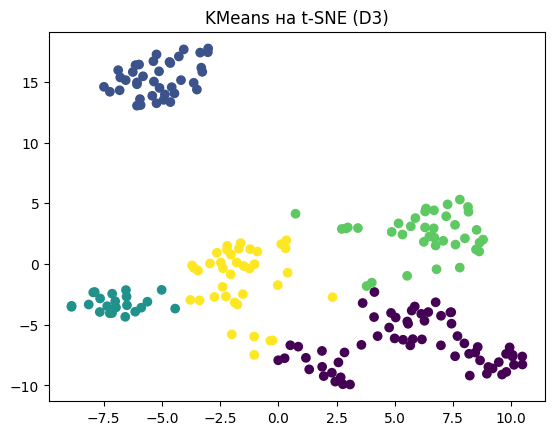


KMeans на D2
Silhouette: 0.5826787948608398
Кластеров: 5

Agglomerative на D2
Silhouette: 0.5689330101013184
Кластеров: 5

DBSCAN на D2
Silhouette: not defined (single cluster or noise)
Кластеров: 1


In [37]:
labels_kmeans_d3 = KMeans(n_clusters=5, random_state=42).fit_predict(D3)
labels_agg_d3 = AgglomerativeClustering(n_clusters=5).fit_predict(D3)
labels_db_d3 = DBSCAN(eps=0.5, min_samples=5).fit_predict(D3)

plt.scatter(D3[:,0], D3[:,1], c=labels_kmeans_d3)
plt.title("KMeans на t-SNE (D3)")
plt.show()

evaluate("KMeans на D2", D3, labels_kmeans_d3)
evaluate("Agglomerative на D2", D3, labels_agg_d3)
evaluate("DBSCAN на D2", D3, labels_db_d3)

### 7. Сделайте выводы о том, какой метод кластеризации и почему оказался лучше для каждого из датасетов.

Наиболее качественные результаты на D1 показал метод KMeans, так как он продемонстрировал наибольшее значение коэффициента силуэта.

Метод Agglomerative Clustering показал сопоставимое, но немного более низкое качество, что связано с его чувствительностью к структуре данных и способу объединения кластеров.

DBSCAN показал худший результат, так как при выбранных параметрах он сформировал менее устойчивые кластеры и частично выделил шум, что снизило значение силуэта.

Лучший метод на D1: KMeans
Причина: данные имеют относительно компактную структуру, хорошо разделяемую на “сферические” кластеры.

На PCA-преобразованных данных качество кластеризации немного снизилось по сравнению с D1.

Лучшие результаты также показал KMeans, однако разница с Agglomerative минимальна.

DBSCAN на D2 выделил меньше кластеров (2), что говорит о том, что в пространстве PCA данные стали более “сжатыми”, и плотностный подход хуже разделяет группы.

Лучший метод на D2: KMeans (незначительно лучше Agglomerative)
Причина: PCA сохраняет глобальную структуру, но уменьшает разделимость кластеров, что ухудшает работу плотностных методов.

На t-SNE представлении наблюдается значительное улучшение качества кластеризации по сравнению с D1 и D2.

Лучшие результаты показал KMeans, с наибольшим значением силуэта (~0.58), немного опережая Agglomerative Clustering.

DBSCAN не смог корректно разделить данные (образовал один кластер), что связано с особенностями t-SNE, который искажает глобальные расстояния и делает плотностные методы менее стабильными.

Лучший метод на D3: KMeans
Причина: t-SNE формирует хорошо визуально разделимые компактные группы, которые KMeans эффективно аппроксимирует.